In [1]:
# objective: generate the particle size structure for the CMIP6 models
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import xarray as xr
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob,os,subprocess
from glob import glob
import IPython.display as display
%matplotlib inline
from datetime import datetime as dt
import matplotlib.gridspec as gridspec
from matplotlib import ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import scipy.stats as st

<h1><center> Mean climatology and data </center></h1>

In [2]:

df_climatology_full = pd.read_csv('/Users/mc4214/CMIP6_biome_PSS_data/CMIP6_data_full_biovolume.csv', sep= ',', index_col = False)
#df_climatology_full = pd.read_csv('/Users/mc4214/Documents/CMIP6_PSS_paper/data/biom_climatology_all_biovolume.csv', sep= ',', index_col = False)
df_climatology_full['biovol_log']=np.log10(df_climatology_full.total_biovolume)
#df_climatology_full = df_climatology_full.loc[(df_climatology_full.source != 'GISS')].reset_index(drop=True)
df_clim_mean = df_climatology_full.astype(dict(zip(['month'],[str]))).groupby(['month', 'experiment', 'biomes','source']).apply(lambda x: pd.Series({

                                                                    'slope':np.nanmean(x.slope),
                                                                    'intercept':np.nanmean(x.intercept),
                                                                    'R2':np.nanmean(x.R2),
                                                                    'total_biovolume':np.nanmean(x.total_biovolume)})).reset_index()
#df_clim_mean['source'] = 'models'
df_clim_mean['month'] = df_clim_mean['month'].astype('float')
df_climatology_full['intercept_un']= (df_climatology_full['intercept'])#10**(df_climatology_full['intercept'])
df_clim_mean

,month,experiment,biomes,source,slope,intercept,R2,total_biovolume
0,1.0,hist,HCPS,CESM,-1.045892,2.259949e+13,0.969896,3.475176e+13
1,1.0,hist,HCPS,CMCC,-1.138508,5.147116e+13,0.988529,9.434310e+13
2,1.0,hist,HCPS,CNRM,-1.236296,4.135723e+14,0.936419,3.896722e+13
3,1.0,hist,HCPS,GFDL,-1.152786,1.194688e+15,0.986870,2.319531e+14
4,1.0,hist,HCPS,GISS,-1.637858,6.796821e+17,0.951476,3.627487e+13
...,...,...,...,...,...,...,...,...
499,9.0,ssp5,LC,CNRM,-1.303323,4.737515e+14,0.950936,1.349898e+13
500,9.0,ssp5,LC,GFDL,-1.181614,6.319084e+14,0.994295,9.785391e+13
501,9.0,ssp5,LC,GISS,-1.796062,1.296285e+18,0.938126,4.832357e+12
502,9.0,ssp5,LC,IPSL,-1.311207,4.308665e+14,0.957573,1.124473e+13


In [3]:
np.nanmean(df_clim_mean.slope[df_clim_mean['experiment']=='hist'])

-1.2542950866651053

In [4]:
np.nanmean(df_clim_mean.slope[df_clim_mean['experiment']=='ssp5'])

-1.2601261642653758

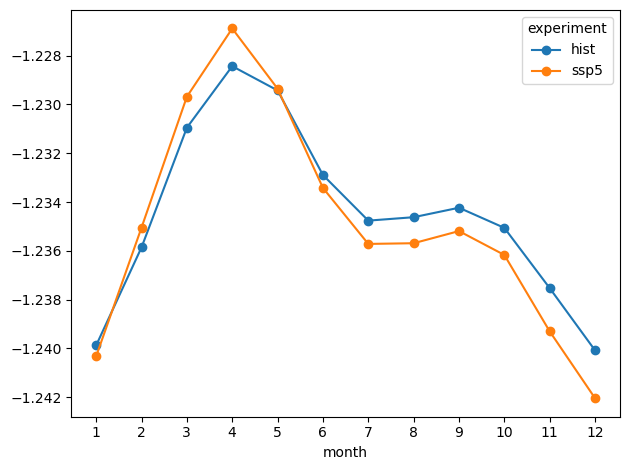

In [5]:
(df_clim_mean.query("experiment in ['hist','ssp5'] and biomes=='HCPS'")
 .groupby(['month','experiment'])['slope'].mean().unstack()
 .plot(marker='o')); plt.xticks(range(1,13)); plt.tight_layout()

In [6]:
from matplotlib.legend import Legend
from matplotlib.ticker import FormatStrFormatter
import matplotlib.ticker as tick
def y_fmt(x, y):
    return '${:1.0e}'.format(x).replace('e', '\\times 10^{') + '}$'

In [7]:
df_clim_mean.loc[(df_clim_mean.source=='UKESM') & (df_clim_mean.experiment=='hist')]

,month,experiment,biomes,source,slope,intercept,R2,total_biovolume
6,1.0,hist,HCPS,UKESM,-1.192191,1.954906e+14,0.986672,4.834470e+13
13,1.0,hist,HCSS,UKESM,-1.217007,1.804368e+14,0.984629,1.474108e+13
20,1.0,hist,LC,UKESM,-1.302723,1.963116e+14,0.989521,1.255225e+13
48,10.0,hist,HCPS,UKESM,-1.173758,1.549129e+14,0.986526,5.360104e+13
55,10.0,hist,HCSS,UKESM,-1.164171,1.342078e+14,0.983998,4.455607e+13
62,10.0,hist,LC,UKESM,-1.278097,1.782031e+14,0.989491,1.515187e+13
90,11.0,hist,HCPS,UKESM,-1.180953,1.542344e+14,0.986862,4.798430e+13
97,11.0,hist,HCSS,UKESM,-1.177089,1.293132e+14,0.984382,3.025897e+13
104,11.0,hist,LC,UKESM,-1.282715,1.668102e+14,0.989626,1.390093e+13
132,12.0,hist,HCPS,UKESM,-1.189302,1.681331e+14,0.987002,4.527921e+13


In [8]:
df_clim_mean.source.unique()

array(['CESM', 'CMCC', 'CNRM', 'GFDL', 'GISS', 'IPSL', 'UKESM'],
      dtype=object)

In [9]:
df_PSSdb = pd.read_csv('/Users/mc4214/Documents/CMIP6_PSS_paper/data/PSSdb_data/PSSdb_data_full.csv', sep= ',')
df_PSSdb['intercept_un']= 10**(df_PSSdb['intercept'])
df_PSSdb['biovol_log']= np.log10(df_PSSdb['subset_biovolume'])# this is the major change to correclty load the subsetted biovol
df_PSSdb

,lat,lon,biomes,cell_area,month,slope,intercept,R2,subset_biovolume,total_biovolume,season,experiment,source,intercept_un,biovol_log
0,80.5,69.5,HCSS,2040.674145,8.0,-0.71160,10.534895,0.94760,6.006215e+13,1.251912e+14,Summer,obs,PSSdb,3.426846e+10,13.778601
1,79.5,60.5,HCSS,2253.188243,8.0,-1.01360,13.587905,0.96615,5.283068e+14,1.134429e+15,Summer,obs,PSSdb,3.871730e+13,14.722886
2,79.5,66.5,HCSS,2253.188243,7.0,-0.72790,11.050613,0.86505,5.067072e+14,2.332618e+15,Summer,obs,PSSdb,1.123603e+11,14.704757
3,79.5,69.5,HCSS,2253.188243,8.0,-0.82940,12.245196,0.98330,3.000293e+14,9.812910e+14,Summer,obs,PSSdb,1.758717e+12,14.477164
4,79.5,71.5,HCSS,2253.188243,7.0,-0.68490,10.892050,0.95075,6.492909e+14,3.713071e+15,Summer,obs,PSSdb,7.799207e+10,14.812439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1212,-57.5,-67.5,HCSS,6643.255521,7.0,-0.58180,9.593316,0.90310,9.906945e+13,9.906945e+13,Summer,obs,PSSdb,3.920266e+09,13.995940
1213,-60.5,-60.5,HCSS,6088.401114,7.0,-1.01455,13.387113,0.94335,2.897377e+14,4.870905e+14,Summer,obs,PSSdb,2.438445e+13,14.462005
1214,-62.5,-49.5,HCSS,5709.131323,7.0,-0.64370,7.890369,0.97900,5.755103e+11,2.112083e+12,Summer,obs,PSSdb,7.769074e+07,11.760053
1215,-64.5,-53.5,HCSS,5322.905835,7.0,-0.72810,11.329196,0.94540,2.568416e+14,1.074861e+15,Summer,obs,PSSdb,2.134008e+11,14.409665


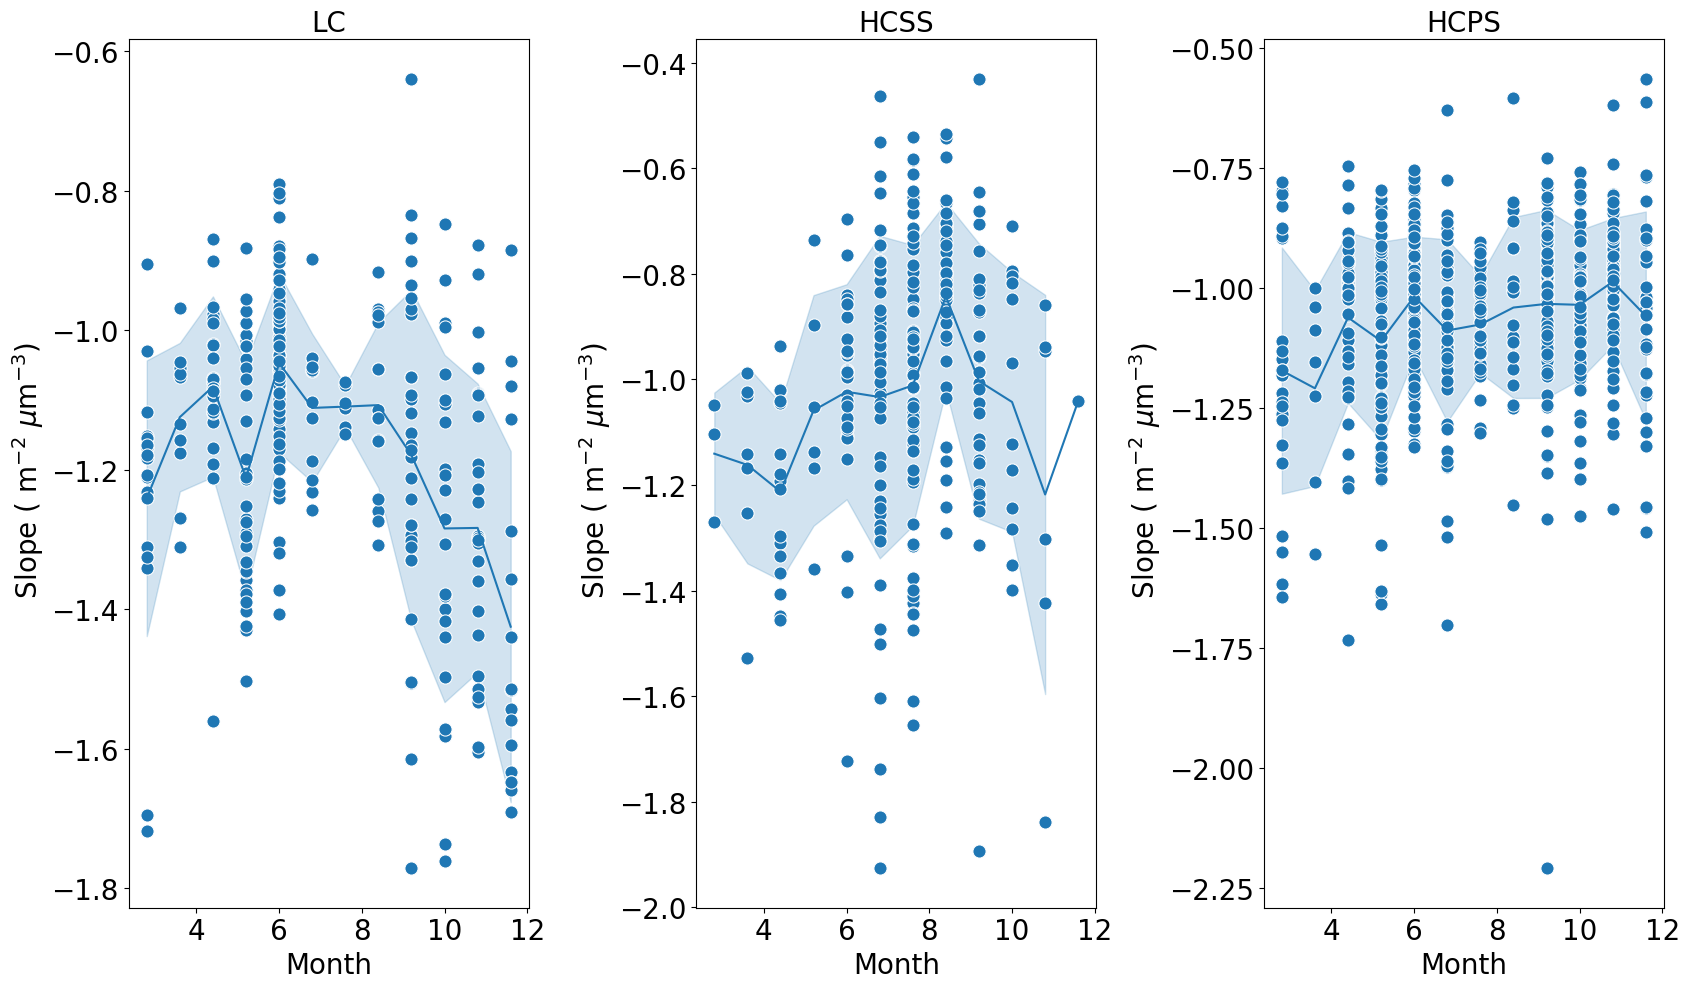

In [10]:
#df_climatology_full = df_climatology_full.loc[df_climatology_full.source != 'GISS'].reset_index()
biome_list = ['LC', 'HCSS', 'HCPS']

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(17,10))

for c, m in enumerate(biome_list):
    ax_n = axs[c]
    #palette = {'CESM': 'tab:red','CMCC': 'tab:blue','CNRM': 'tab:gray','GFDL': 'tab:green','IPSL': 'tab:yellow','UKESM': 'tab:purple'}
    sns.lineplot(ax = ax_n,x = 'month', y='slope',  data=df_PSSdb[df_PSSdb['biomes']== m], ci = 'sd')
    sns.scatterplot(ax=ax_n, x='month', y='slope',  s=90, data=df_PSSdb[df_PSSdb['biomes']== m])
    ax_n.set_title(m, fontsize=20)
    ax_n.tick_params(axis='both', which='major', labelsize=20)
    ax_n.set_ylabel(r' Slope ( m$^{-2}$ $\mu$m$^{-3}$)', fontsize = 20)
    ax_n.set_xlabel('Month', fontsize=20)
    ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
    #ax_n.set_ylim(-1.6, -1.2)

    ax_n.set_xticklabels([2,4,6,8,10,12], fontsize=20)
           
plt.tight_layout()
#plt.savefig('/work/m1c/CMIP6_size_spectra_scripts/plots/fig_biomes_climatology_mean_slope_PSSdb_ONLY_w-CI_new_HCSS.pdf', dpi=300)


In [11]:
np.nanmin(df_PSSdb['intercept'])

6.2929584794248346

In [12]:
np.nanmax(df_PSSdb['intercept'])

25.17307844348342

In [13]:

df_PSSdb_mean = df_PSSdb.astype(dict(zip(['month'],[str]))).groupby(['source','month', 'experiment', 'biomes']).apply(lambda x: pd.Series({

                                                                    'slope':np.nanmean(x.slope),
                                                                    'intercept':np.nanmean(x.intercept),
                                                                    'R2':np.nanmean(x.R2),
    
                                                                    'total_biovolume':np.nanmean(x.biovol_log)})).reset_index()
    
df_PSSdb_mean['month'] = df_PSSdb_mean['month'].astype('float')
df_PSSdb_mean['total_biovolume']=10**(df_PSSdb_mean.total_biovolume)
df_PSSdb_mean['intercept_un']= 10**(df_PSSdb_mean['intercept'])
df_PSSdb_mean

,source,month,experiment,biomes,slope,intercept,R2,total_biovolume,intercept_un
0,PSSdb,1.0,obs,HCPS,-1.172470,14.497764,0.969098,1.129374e+14,3.146036e+14
1,PSSdb,1.0,obs,HCSS,-1.140587,13.421883,0.970421,2.799259e+13,2.641696e+13
2,PSSdb,1.0,obs,LC,-1.240656,15.054239,0.974592,1.067149e+14,1.133024e+15
3,PSSdb,10.0,obs,HCPS,-1.035480,13.367231,0.966694,1.052964e+14,2.329329e+13
4,PSSdb,10.0,obs,HCSS,-1.042693,13.379458,0.959509,1.434842e+14,2.395838e+13
5,PSSdb,10.0,obs,LC,-1.283974,15.040825,0.950611,4.814071e+13,1.098562e+15
6,PSSdb,11.0,obs,HCPS,-0.987511,13.031767,0.973445,1.337723e+14,1.075888e+13
7,PSSdb,11.0,obs,HCSS,-1.217904,14.287079,0.961039,2.624634e+13,1.936776e+14
8,PSSdb,11.0,obs,LC,-1.283196,15.150357,0.959163,6.754673e+13,1.413698e+15
9,PSSdb,12.0,obs,HCPS,-1.058606,13.640303,0.963506,1.250553e+14,4.368204e+13


In [14]:
#df_clim = pd.concat([df_clim_mean, df_PSSdb]).reset_index()
#df_climatology_full = pd.concat([df_climatology_full, df_PSSdb]).reset_index()


In [15]:
df_clim_mean.source.unique()

array(['CESM', 'CMCC', 'CNRM', 'GFDL', 'GISS', 'IPSL', 'UKESM'],
      dtype=object)

In [16]:
palette_source = dict(CESM= '#0077BB',CMCC= '#33BBEE', CNRM= '#009988',GFDL= '#EE7733', GISS= '#CC3311', IPSL= '#EE3377',UKESM= '#BBBBBB', PSSdb = 'black')
palette_experiments= dict(hist='rosybrown', ssp5='firebrick', obs='black')
letters_clim = ['a.','b.','c.',  'd.','e.','f.',  'g.','h.','i.']

In [17]:
df_hist= df_climatology_full.loc[(df_climatology_full.experiment == 'hist') & (df_climatology_full.source != 'GISS')]
df_hist_GISS= df_climatology_full.loc[(df_climatology_full.experiment == 'hist') & (df_climatology_full.source == 'GISS')]

In [18]:
df_hist

,lat,lon,month,biomes,slope,intercept,R2,total_biovolume,experiment,source,season,biovol_log,intercept_un
0,-77.5,-179.5,1.0,HCSS,-0.907265,1.448721e+11,0.976717,3.604478e+12,hist,CESM,Winter,12.556842,1.448721e+11
1,-77.5,-178.5,1.0,HCSS,-0.909153,1.584194e+11,0.976510,3.791176e+12,hist,CESM,Winter,12.578774,1.584194e+11
2,-77.5,-177.5,1.0,HCSS,-0.911068,1.739923e+11,0.976300,3.999223e+12,hist,CESM,Winter,12.601976,1.739923e+11
3,-77.5,-176.5,1.0,HCSS,-0.912826,1.916664e+11,0.976097,4.241474e+12,hist,CESM,Winter,12.627517,1.916664e+11
4,-77.5,-175.5,1.0,HCSS,-0.914441,2.114271e+11,0.975898,4.516142e+12,hist,CESM,Winter,12.654768,2.114271e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2092495,77.5,177.5,12.0,HCSS,-1.113644,1.845865e+12,0.985532,1.491560e+12,hist,UKESM,Winter,12.173641,1.845865e+12
2092496,77.5,178.5,12.0,HCSS,-1.114195,1.838267e+12,0.985576,1.470271e+12,hist,UKESM,Winter,12.167397,1.838267e+12
2092497,77.5,179.5,12.0,HCSS,-1.114762,1.833484e+12,0.985618,1.451002e+12,hist,UKESM,Winter,12.161668,1.833484e+12
2092498,78.5,-165.5,12.0,HCSS,-1.124500,1.710199e+12,0.986412,1.143188e+12,hist,UKESM,Winter,12.058118,1.710199e+12


In [19]:
# Run this cell to make the figures without GISS
df_clim_mean = df_clim_mean.loc[df_clim_mean.source != 'GISS'].reset_index()
df_climatology_full = df_climatology_full.loc[df_climatology_full.source != 'GISS'].reset_index()

In [20]:
df_climatology_full.source.unique()

array(['CESM', 'CMCC', 'CNRM', 'GFDL', 'IPSL', 'UKESM'], dtype=object)

In [21]:
#df_climatology_full['intercept_trans'] = np.log10(df_climatology_full['intercept'])
df_clim_mean['intercept_trans'] = np.log10(df_clim_mean['intercept'])
df_mean_experiments = df_clim_mean.astype(dict(zip(['month'],[str]))).groupby(['month', 'experiment', 'biomes']).apply(lambda x: pd.Series({

                                                                    'slope':np.nanmean(x.slope),
                                                                    'intercept_trans':np.nanmean(x.intercept_trans),
    
                                                                    'total_biovolume':np.nanmean(x.total_biovolume)})).reset_index()
df_mean_experiments['month'] = df_mean_experiments['month'].astype('float')
df_mean_experiments['intercept_un']= 10**(df_mean_experiments['intercept_trans'])
df_mean_experiments

,month,experiment,biomes,slope,intercept_trans,total_biovolume,intercept_un
0,1.0,hist,HCPS,-1.173552,14.283489,7.815960e+13,1.920832e+14
1,1.0,hist,HCSS,-1.150452,14.052630,4.928522e+13,1.128834e+14
2,1.0,hist,LC,-1.222575,14.224042,3.608427e+13,1.675104e+14
3,1.0,ssp5,HCPS,-1.173392,14.263479,7.225272e+13,1.834338e+14
4,1.0,ssp5,HCSS,-1.149444,14.004484,4.372782e+13,1.010377e+14
...,...,...,...,...,...,...,...
67,9.0,hist,HCSS,-1.149983,14.232885,1.114672e+14,1.709563e+14
68,9.0,hist,LC,-1.213639,14.232351,3.997117e+13,1.707461e+14
69,9.0,ssp5,HCPS,-1.169401,14.263958,8.087220e+13,1.836359e+14
70,9.0,ssp5,HCSS,-1.155069,14.210551,1.015714e+14,1.623869e+14


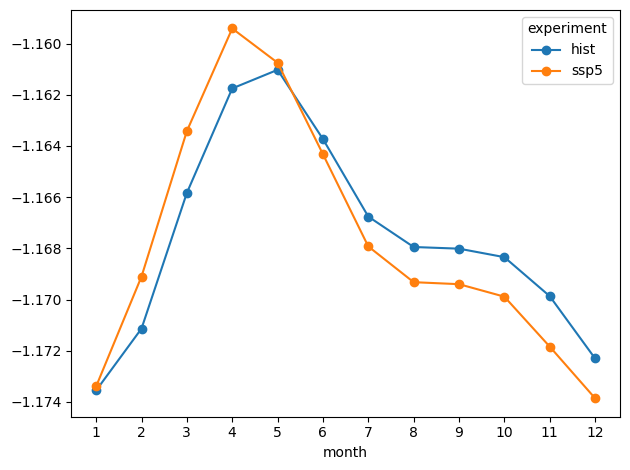

In [22]:
(df_mean_experiments.query("experiment in ['hist','ssp5'] and biomes=='HCPS'")
 .groupby(['month','experiment'])['slope'].mean().unstack()
 .plot(marker='o')); plt.xticks(range(1,13)); plt.tight_layout()

In [23]:
from matplotlib import ticker as mtick
from matplotlib.ticker import MaxNLocator

In [24]:
df_clim_mean.source

0       CESM
1       CMCC
2       CNRM
3       GFDL
4       IPSL
       ...  
427     CMCC
428     CNRM
429     GFDL
430     IPSL
431    UKESM
Name: source, Length: 432, dtype: object

## Slope

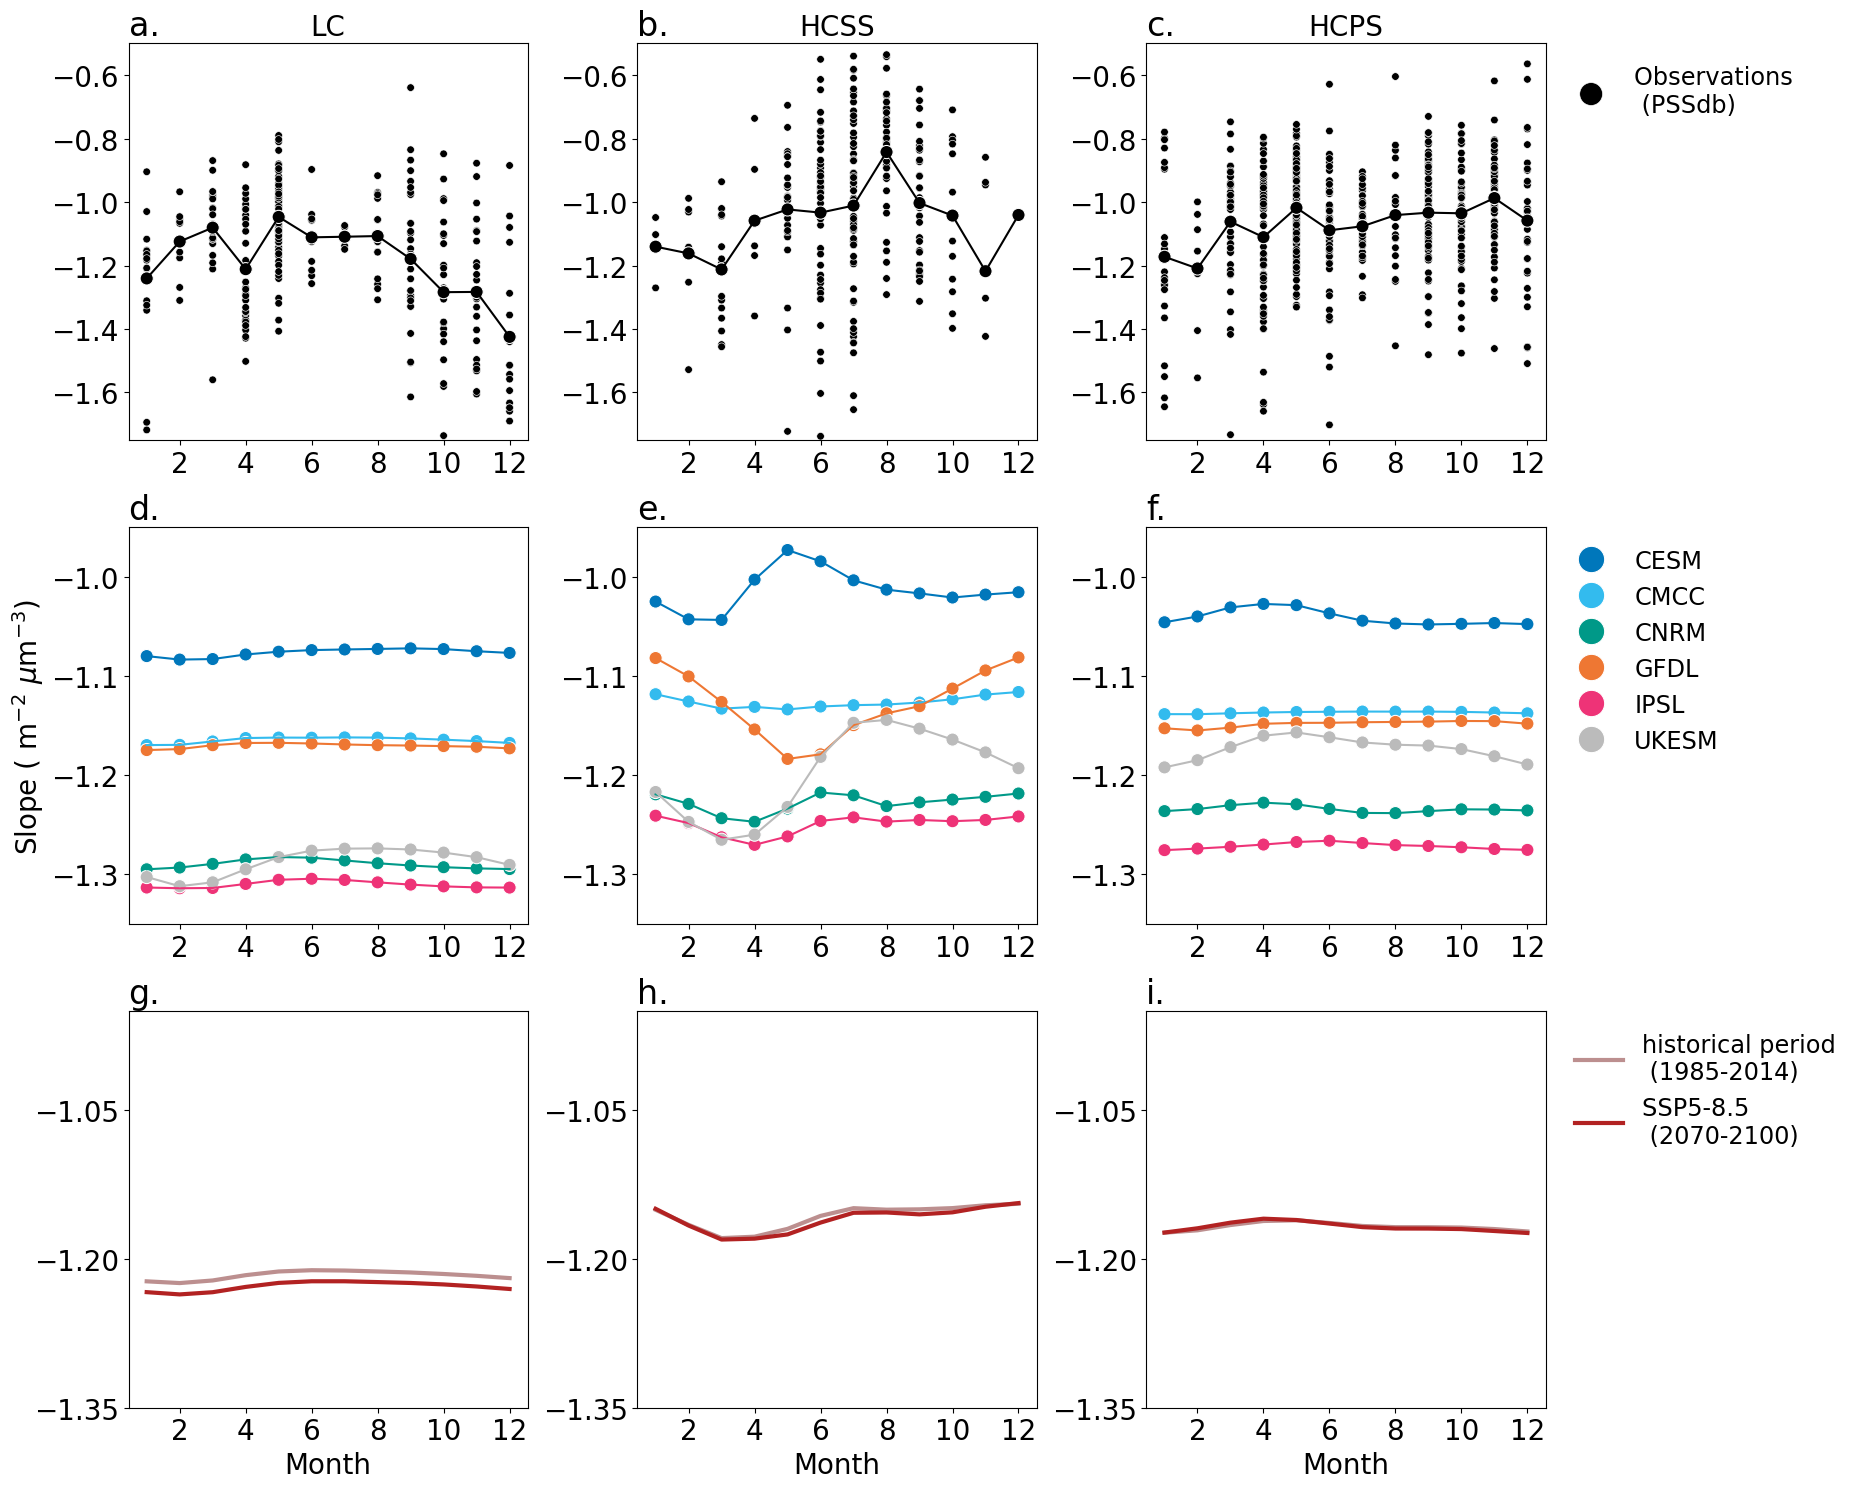

In [25]:


biome_list = ['LC', 'HCSS', 'HCPS']
ind=0
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(19,15))
# these next lines ensure that only climatologies with negative correlation are plotted

for r in [0,1,2]:
    for c, m in enumerate(biome_list):
        ax_n = axs[r,c]
        ind +=1
        ax_n.set_title(letters_clim[ind-1], loc='left', fontsize=24)
        if r==0:
            sns.scatterplot(ax=ax_n, x='month', y='slope', hue='source', markers=[ "o"], palette=palette_source, s=30, data=df_PSSdb[df_PSSdb['biomes']== m], legend=False)
            sns.scatterplot(ax=ax_n, x='month', y='slope', hue='source', markers=[ "o"], palette=palette_source, s=90, data=df_PSSdb_mean[df_PSSdb_mean['biomes']== m])
            sns.lineplot(ax=ax_n, x='month', y='slope', hue='source', palette=palette_source, data=df_PSSdb[df_PSSdb['biomes']== m], ci=None, legend=False)
            ax_n.set_title(m, fontsize=20)
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('')
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            ax_n.set_ylim( -1.75, -0.5)
            #if c <2:
                #ax_n.get_legend().remove()
            if c <2:
                ax_n.get_legend().remove()
            elif c==2:
                ax_n.legend(['Observations \n (PSSdb)'],fontsize = 'xx-large',  markerscale=3, frameon=False, bbox_to_anchor=(1, 1))
        elif r==1:
            sns.scatterplot(ax=ax_n, x='month', y='slope', hue='source', markers=["o"], palette=palette_source, s=90, data=df_clim_mean[(df_clim_mean['biomes']== m) & (df_clim_mean.experiment=='hist')])
            sns.lineplot(ax=ax_n, x='month', y='slope', hue='source', palette=palette_source, data=df_clim_mean[(df_clim_mean['biomes']== m) & (df_clim_mean.experiment=='hist')], legend=False)
            ax_n.set_title('')
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('')
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            if c==0:
                ax_n.set_ylabel(r'Slope ( m$^{-2}$ $\mu$m$^{-3}$)', fontsize = 20)
            else:
                ax_n.set_ylabel('')
            if c <2:
                ax_n.get_legend().remove()
            elif c==2:
                ax_n.legend(fontsize = 'xx-large',  markerscale=2, frameon=False, bbox_to_anchor=(1, 1))
                
            #ax_n.set_yticklabels([-1.1, -0.9, -0.7], fontsize=20) #[-1.6, -1.4, -1.2, -1.0]
            ax_n.set_ylim(-1.35, -0.95)#
        else:
            #palette = {'CESM': 'tab:red','CMCC': 'tab:blue','CNRM': 'tab:gray','GFDL': 'tab:green','IPSL': 'tab:yellow','UKESM': 'tab:purple'}
            sns.lineplot(ax = ax_n,x = 'month', y='slope', hue = 'experiment',hue_order=['hist', 'ssp5', 'obs'],palette=palette_experiments, data=df_mean_experiments[df_mean_experiments['biomes']== m], linewidth = 3, ci=None)

            ax_n.set_title('')
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('Month', fontsize=20)
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            ax_n.yaxis.set_major_locator(plt.MaxNLocator(4))
            if c <2:
                ax_n.get_legend().remove()
            elif c==2:
                ax_n.legend(['historical period \n (1985-2014)', 'SSP5-8.5 \n (2070-2100)'], fontsize = 'xx-large',  markerscale=10, frameon=False, bbox_to_anchor=(1.8, 1))
            ax_n.set_ylim(-1.35, -0.95)
        ax_n.xaxis.set_major_locator(MaxNLocator(integer=True))
        
plt.tight_layout()
plt.savefig('/Users/mc4214/GIT/CMIP6_size_spectra/figures/fig_biomes_climatology_mean_slope_PSSdb_new_HCSS_No_GISS.png', dpi=300)

## Intercept

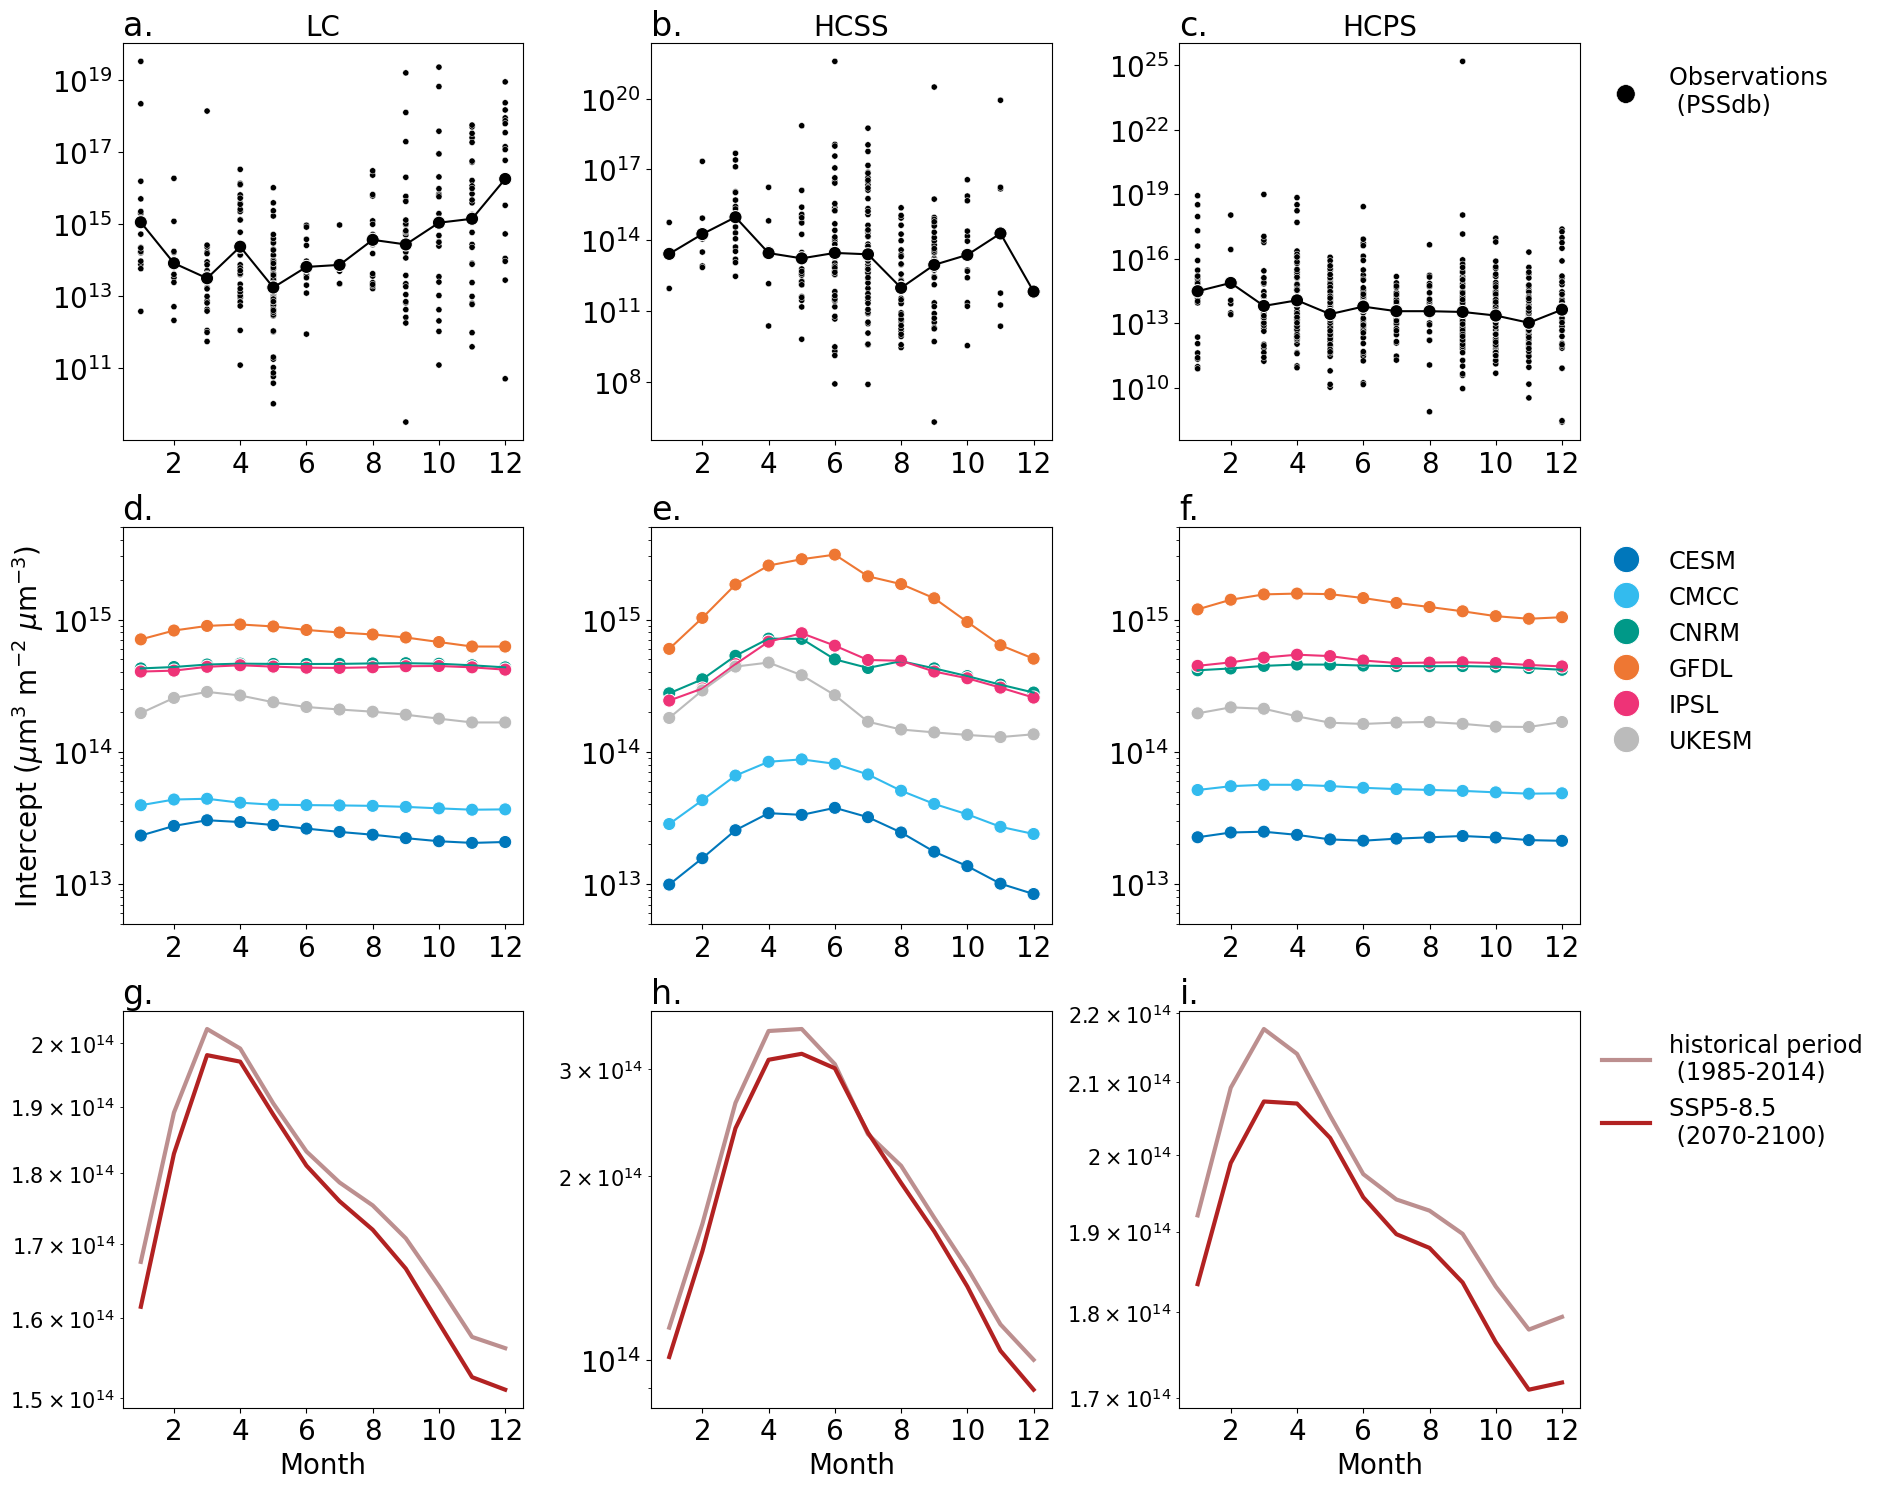

In [26]:

biome_list = ['LC', 'HCSS', 'HCPS']
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(19,15))
# these next lines ensure that only climatologies with negative correlation are plotted
ind=0
for r in [0,1,2]:
    for c, m in enumerate(biome_list):
        ax_n = axs[r,c]
        ind +=1
        ax_n.set_title(letters_clim[ind-1], loc='left', fontsize=24)
        if r==0:
            sns.scatterplot(ax=ax_n, x='month', y='intercept_un', hue='source', markers=[ "o"], palette=palette_source, s=20, data=df_PSSdb[df_PSSdb['biomes']== m], legend=False)
            sns.scatterplot(ax=ax_n, x='month', y='intercept_un', hue='source', markers=[ "o"], palette=palette_source, s=90, data=df_PSSdb_mean[df_PSSdb_mean['biomes']== m])
            sns.lineplot(ax=ax_n, x='month', y='intercept_un', hue='source', palette=palette_source, data=df_PSSdb_mean[df_PSSdb_mean['biomes']== m], ci=None, legend=False)
            ax_n.set_title(m, fontsize=20)
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('')
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            #ax_n.set_ylim(9, 20)
            if c <2:
                ax_n.get_legend().remove()
            elif c==2:
                ax_n.legend(['Observations \n (PSSdb)'],fontsize = 'xx-large',  markerscale=3, frameon=False, bbox_to_anchor=(1, 1))

        elif r==1:
            sns.scatterplot(ax=ax_n, x='month', y='intercept', hue='source', markers=["o"], palette=palette_source, s=90, data=df_clim_mean[(df_clim_mean['biomes']== m) & (df_clim_mean.experiment=='hist')])
            sns.lineplot(ax=ax_n, x='month', y='intercept', hue='source', palette=palette_source, data=df_clim_mean[(df_clim_mean['biomes']== m) & (df_clim_mean.experiment=='hist')], legend=False)
            ax_n.set_title('')
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.set_xlabel('')
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            if c <2:
                ax_n.get_legend().remove()
            elif c==2:
                 ax_n.legend(fontsize = 'xx-large',  markerscale=2, frameon=False, bbox_to_anchor=(1, 1))

            if c==0:
                ax_n.set_ylabel(r'Intercept ($\mu$m$^{3}$ m$^{-2}$ $\mu$m$^{-3}$)', fontsize = 20)
            else:
                ax_n.set_ylabel('')
            ax_n.set_ylim(5e12, 5e15)
        else:
            #palette = {'CESM': 'tab:red','CMCC': 'tab:blue','CNRM': 'tab:gray','GFDL': 'tab:green','IPSL': 'tab:yellow','UKESM': 'tab:purple'}
            sns.lineplot(ax = ax_n,x = 'month', y='intercept_un', hue = 'experiment',hue_order=['hist', 'ssp5', 'obs'],palette = palette_experiments, data=df_mean_experiments[df_mean_experiments['biomes']== m], linewidth = 3, ci=None)
            ax_n.set_title('')
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.tick_params(axis='both', which='minor', labelsize=15)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('Month', fontsize=20)
            ax_n.set_yticklabels([2e14, 4e14,6e14,8e14])
            #ax_n.set_ylim(0.8e14, 10e14)
            if c <2:
                ax_n.get_legend().remove()
            elif c==2:
                ax_n.legend(['historical period \n (1985-2014)', 'SSP5-8.5 \n (2070-2100)'], fontsize = 'xx-large',  markerscale=10, frameon=False, bbox_to_anchor=(1, 1))

        ax_n.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_n.set_yscale('log')
           
plt.tight_layout()
#plt.savefig('/Users/mc4214/GIT/CMIP6_size_spectra/figures/fig_biomes_climatology_mean_intercept_PSSdb_new_HCSS_No_GISS.pdf', dpi=300)

## biovolume

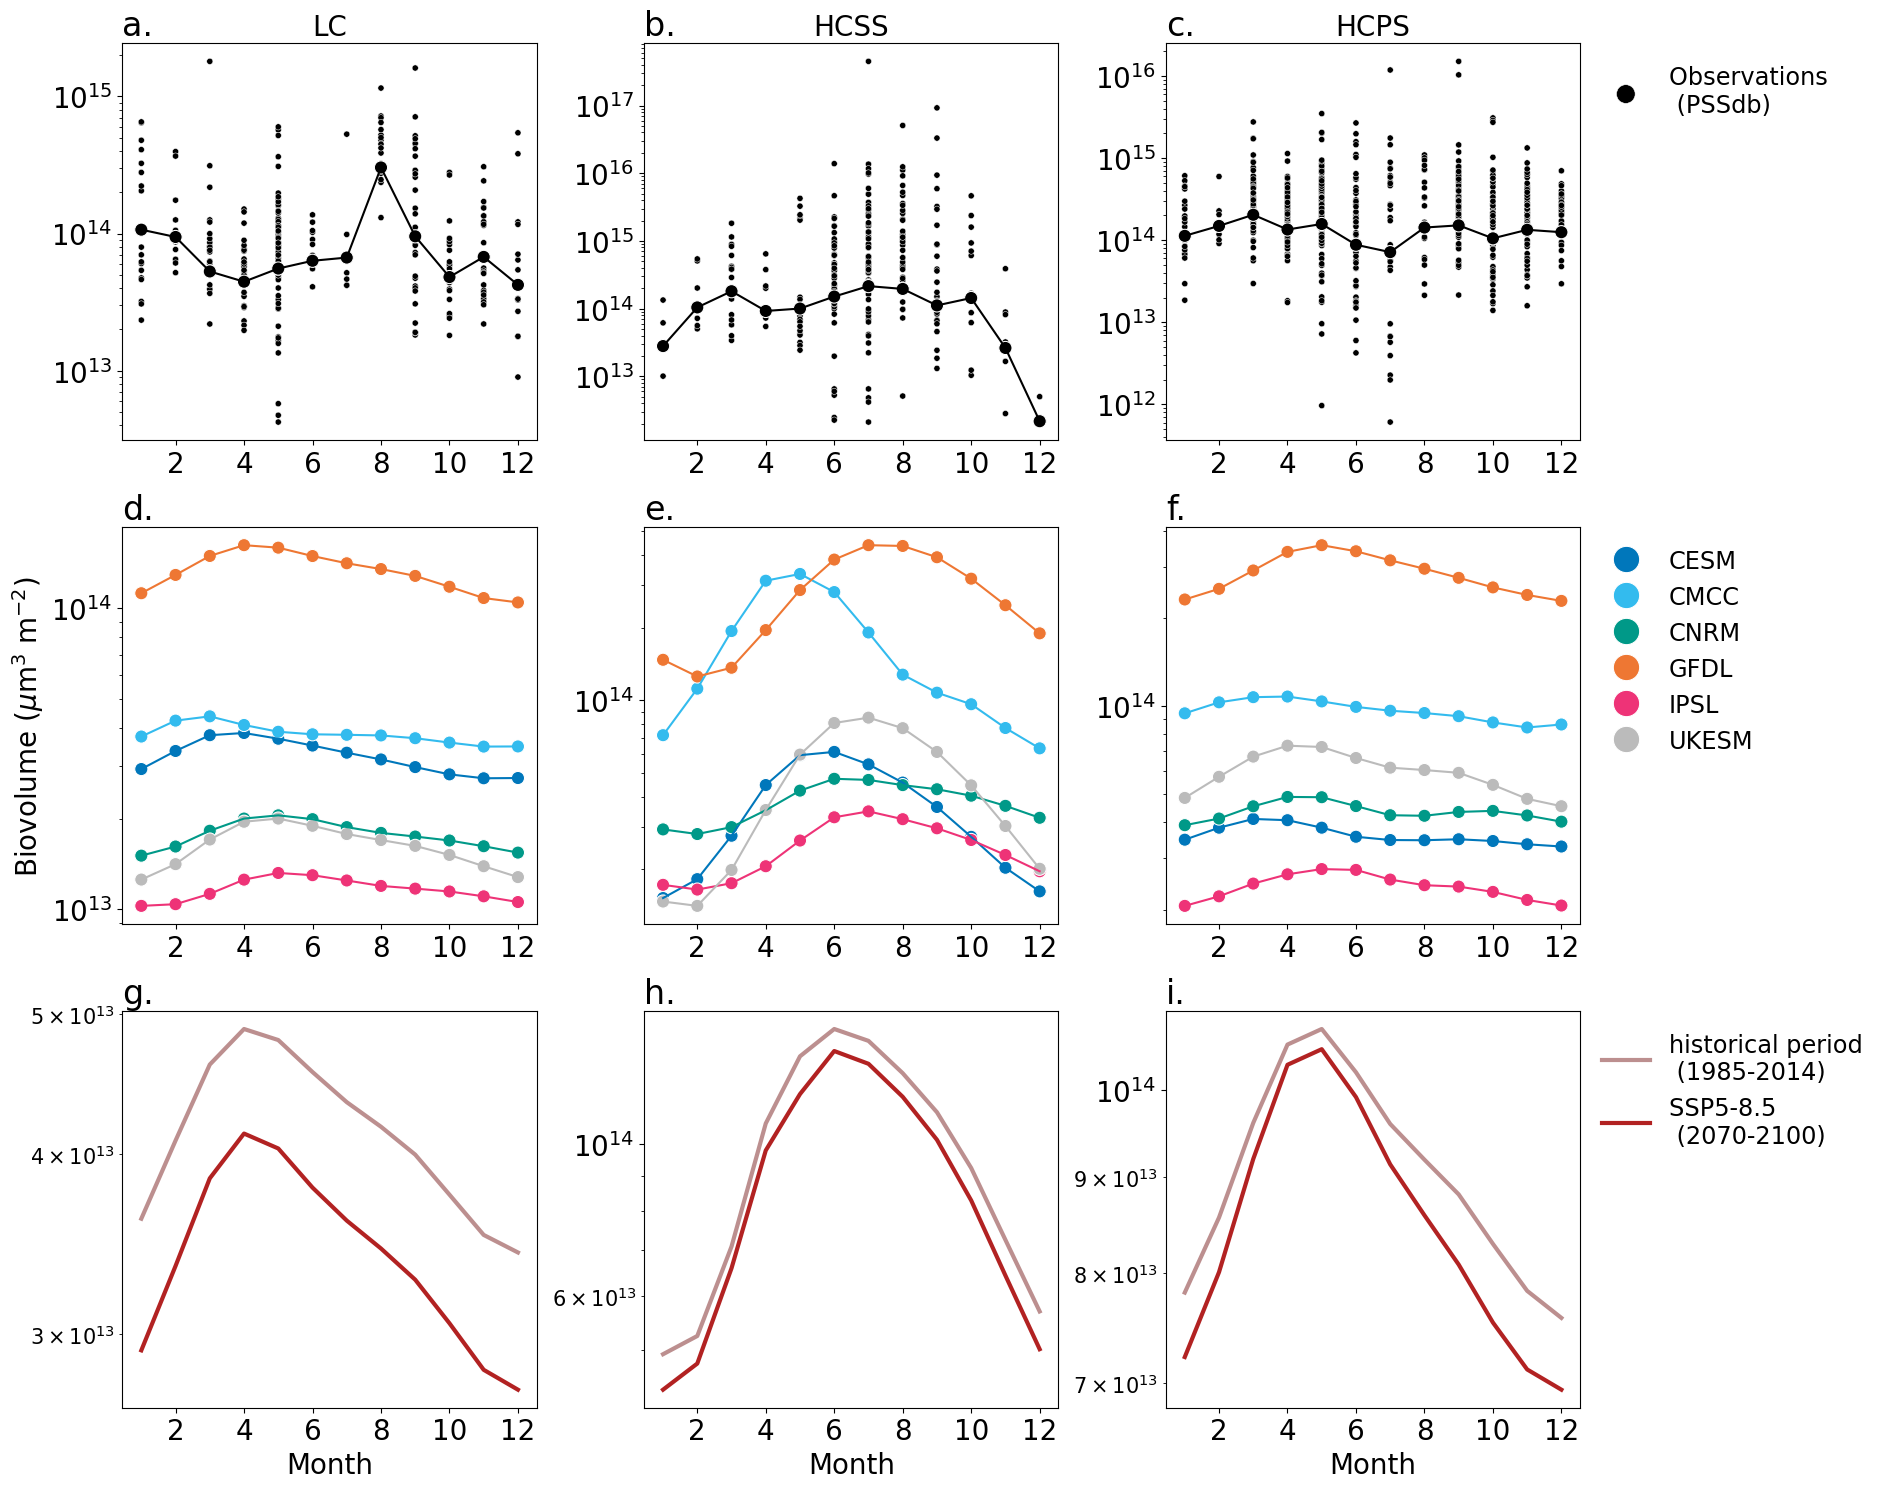

In [27]:
#df_climatology_full = df_climatology_full.loc[df_climatology_full.source != 'GISS'].reset_index()
biome_list = ['LC', 'HCSS', 'HCPS']
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(19,15))
ind=0

for r in [0,1,2]:
    for c, m in enumerate(biome_list):
        ax_n = axs[r,c]
        ind +=1
        ax_n.set_title(letters_clim[ind-1], loc='left', fontsize=24)
        if r==0:
            sns.scatterplot(ax=ax_n, x='month', y='total_biovolume', hue='source', markers=[ "o"], palette=palette_source, s=20, data=df_PSSdb[df_PSSdb['biomes']== m], legend=False)
            sns.scatterplot(ax=ax_n, x='month', y='total_biovolume', hue='source',markers=[ "o"], palette=palette_source, s=90, data=df_PSSdb_mean[df_PSSdb_mean['biomes']== m])
            sns.lineplot(ax=ax_n, x='month', y='total_biovolume', hue='source', palette=palette_source, data=df_PSSdb_mean[df_PSSdb_mean['biomes']== m], ci=None, legend=False)
            ax_n.set_title(m, fontsize=20)
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('')
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            #ax_n.set_ylim(9, 13)
            if c <2:
                ax_n.get_legend().remove()
            elif c==2:
                ax_n.legend(['Observations \n (PSSdb)'],fontsize = 'xx-large',  markerscale=3, frameon=False, bbox_to_anchor=(1, 1))

        elif r==1:
            sns.scatterplot(ax=ax_n, x='month', y='total_biovolume', hue='source', markers=["o"], palette=palette_source, s=90, data=df_clim_mean[(df_clim_mean['biomes']== m) & (df_clim_mean.experiment=='hist')])
            sns.lineplot(ax=ax_n, x='month', y='total_biovolume', hue='source', palette=palette_source, data=df_clim_mean[(df_clim_mean['biomes']== m) & (df_clim_mean.experiment=='hist')], legend=False)
            ax_n.set_title('')
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('')
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            if c==0:
                ax_n.set_ylabel(r'Biovolume ($\mu$m$^{3}$ m$^{-2}$)', fontsize = 20)
            else:
                ax_n.set_ylabel('')
            if c <2:
                ax_n.get_legend().remove()
            elif c==2:
                 ax_n.legend(fontsize = 'xx-large',  markerscale=2, frameon=False, bbox_to_anchor=(1, 1))

            #ax_n.set_ylim(12.5, 15)
        else:
            #palette = {'CESM': 'tab:red','CMCC': 'tab:blue','CNRM': 'tab:gray','GFDL': 'tab:green','IPSL': 'tab:yellow','UKESM': 'tab:purple'}
            sns.lineplot(ax = ax_n,x = 'month', y='total_biovolume', hue='experiment', hue_order=['hist', 'ssp5', 'obs'],palette = palette_experiments, data=df_mean_experiments[df_mean_experiments['biomes']== m],linewidth = 3, ci=None)
            ax_n.set_title('')
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.tick_params(axis='both', which='minor', labelsize=15)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('Month', fontsize=20)
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            if c <2:
                ax_n.get_legend().remove()
            elif c==2:
                ax_n.legend(['historical period \n (1985-2014)', 'SSP5-8.5 \n (2070-2100)'], fontsize = 'xx-large',  markerscale=10, frameon=False, bbox_to_anchor=(1, 1))

        ax_n.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_n.set_yscale('log')
           
plt.tight_layout()
plt.savefig('/Users/mc4214/GIT/CMIP6_size_spectra/figures/fig_biomes_climatology_mean_biovolume_PSSdb_new_HCSS_No_GISS_116-2000.png', dpi=300)

## climatologies for GISS

In [28]:
df_climatology_full = pd.read_csv('/work/m1c/CMIP6_biome_PSS_data/biom_climatology_all_biovolume.csv', sep= ',', index_col = False)
df_climatology_full['biovol_log']=np.log10(df_climatology_full.total_biovolume)
#df_climatology_full = df_climatology_full.loc[(df_climatology_full.source != 'GISS')].reset_index(drop=True)
df_clim_mean = df_climatology_full.astype(dict(zip(['month'],[str]))).groupby(['month', 'experiment', 'biomes','source']).apply(lambda x: pd.Series({

                                                                    'slope':np.nanmean(x.slope),
                                                                    'intercept':np.nanmean(x.intercept),
                                                                    'R2':np.nanmean(x.R2),
                                                                    'total_biovolume':np.nanmean(x.total_biovolume)})).reset_index()
#df_clim_mean['source'] = 'models'
df_clim_mean['month'] = df_clim_mean['month'].astype('float')
df_climatology_full['intercept_un']= (df_climatology_full['intercept'])#10**(df_climatology_full['intercept'])
df_clim_mean

FileNotFoundError: [Errno 2] No such file or directory: '/work/m1c/CMIP6_biome_PSS_data/biom_climatology_all_biovolume.csv'

In [ ]:
#df_climatology_full = df_climatology_full.loc[df_climatology_full.source != 'GISS'].reset_index()
biome_list = ['LC', 'HCSS', 'HCPS']
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(19,15))
ind=0
letters_clim = ['a.','b.','c.', 'd.','e.','f.', 'g.','h.','i.']
for r in [0,1,2]:
    for c, m in enumerate(biome_list):
        ax_n = axs[r,c]
        ind +=1
        ax_n.set_title(letters_clim[ind-1], loc='left', fontsize=24)
        if r==0:
            sns.scatterplot(ax=ax_n, x='month', y='slope', hue='source', markers=[ "o"], palette=palette_source, s=90, data=df_hist_GISS[df_hist_GISS['biomes']== m], legend=False)
            #sns.scatterplot(ax=ax_n, x='month', y='slope', hue='source',markers=[ "o"], palette=palette_source, s=90, data=df_PSSdb_mean[df_PSSdb_mean['biomes']== m])
            sns.lineplot(ax=ax_n, x='month', y='slope', hue='source', palette=palette_source, data=df_hist_GISS[df_hist_GISS['biomes']== m], ci=None, legend=False)
            ax_n.set_title(m, fontsize=20)
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('')
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            #ax_n.set_ylim(9, 13)
            if c==0:
                ax_n.set_ylabel(r'Slope ( m$^{-2}$ $\mu$m$^{-3}$)', fontsize = 20)
        elif r==1:
            sns.scatterplot(ax=ax_n, x='month', y='intercept', hue='source', markers=[ "o"], palette=palette_source, s=90, data=df_hist_GISS[df_hist_GISS['biomes']== m], legend=False)
            #sns.scatterplot(ax=ax_n, x='month', y='slope', hue='source',markers=[ "o"], palette=palette_source, s=90, data=df_PSSdb_mean[df_PSSdb_mean['biomes']== m])
            sns.lineplot(ax=ax_n, x='month', y='intercept', hue='source', palette=palette_source, data=df_hist_GISS[df_hist_GISS['biomes']== m], ci=None, legend=False)
            ax_n.set_title(m, fontsize=20)
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.tick_params(axis='both', which='minor', labelsize=15)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('')
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            ax_n.set_yscale('log')
            #ax_n.set_ylim(9, 13)
            if c==0:
                ax_n.set_ylabel(r'Intercept ($\mu$m$^{3}$ m$^{-2}$ $\mu$m$^{-3}$)', fontsize = 20)
                

        else:
            sns.scatterplot(ax=ax_n, x='month', y='total_biovolume', hue='source', markers=["o"], palette=palette_source, s=90, data=df_hist_GISS[df_hist_GISS['biomes']== m])
            sns.lineplot(ax=ax_n, x='month', y='total_biovolume', hue='source', palette=palette_source, data=df_hist_GISS[df_hist_GISS['biomes']== m], legend=False)
            ax_n.set_title('')
            ax_n.tick_params(axis='both', which='major', labelsize=20)
            ax_n.tick_params(axis='both', which='minor', labelsize=15)
            ax_n.set_ylabel('')
            ax_n.set_xlabel('')
            ax_n.xaxis.set_major_locator(plt.MaxNLocator(6))
            ax_n.set_yscale('log')
            if c==0:
                ax_n.set_ylabel(r'Biovolume ($\mu$m$^{3}$ m$^{-2}$)', fontsize = 20)
            else:
                ax_n.set_ylabel('')
            if c <2:
                ax_n.get_legend().remove()
            elif c==2:
                 ax_n.legend(fontsize = 'xx-large',  markerscale=2, frameon=False, bbox_to_anchor=(1, 1))

            #ax_n.set_ylim(12.5, 15)

        ax_n.xaxis.set_major_locator(MaxNLocator(integer=True))
        
           
plt.tight_layout()
plt.savefig('/work/m1c/CMIP6_size_spectra_scripts/plots/fig_biomes_climatology_all_GISS_only.pdf', dpi=300)